In [8]:
import csv
import json
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

project_root = Path.cwd()
artifacts_dir = project_root / "artifacts"
data_root = project_root / "real_vs_fake" / "real-vs-fake"

In [9]:
summary = {}
for split in ["train", "valid", "test"]:
    counts = Counter()
    csv_path = project_root / f"{split}.csv"
    with csv_path.open("r", newline="", encoding="utf-8") as handle:
        reader = csv.DictReader(handle)
        total = 0
        for row in reader:
            counts[row["label_str"].strip().lower()] += 1
            total += 1
    summary[split] = {
        "total": total,
        "fake": counts["fake"],
        "real": counts["real"],
        "fake_pct": round((counts["fake"] / total) * 100, 2),
        "real_pct": round((counts["real"] / total) * 100, 2),
    }

summary

{'train': {'total': 100000,
  'fake': 50000,
  'real': 50000,
  'fake_pct': 50.0,
  'real_pct': 50.0},
 'valid': {'total': 20000,
  'fake': 10000,
  'real': 10000,
  'fake_pct': 50.0,
  'real_pct': 50.0},
 'test': {'total': 20000,
  'fake': 10000,
  'real': 10000,
  'fake_pct': 50.0,
  'real_pct': 50.0}}

In [10]:
best_valid_path = artifacts_dir / "best_valid_metrics.json"
test_metrics_path = artifacts_dir / "test_metrics.json"

best_valid = json.loads(best_valid_path.read_text(encoding="utf-8")) if best_valid_path.exists() else None
test_metrics = json.loads(test_metrics_path.read_text(encoding="utf-8")) if test_metrics_path.exists() else None
roc_curve_path = artifacts_dir / "best_model_roc_curve.json"

{
    "best_valid": {k: v for k, v in best_valid.items() if k not in {"classification_report", "confusion_matrix", "roc_curve"}} if best_valid else None,
    "test": {k: v for k, v in test_metrics.items() if k not in {"classification_report", "confusion_matrix", "roc_curve"}} if test_metrics else None,
}

{'best_valid': {'loss': 0.4168993078708649,
  'accuracy': 0.83685,
  'f1': 0.8367765494472513,
  'roc_auc': 0.916984075},
 'test': {'loss': 0.4178325711250305,
  'accuracy': 0.83755,
  'f1': 0.8380116667497632,
  'roc_auc': 0.916002695}}

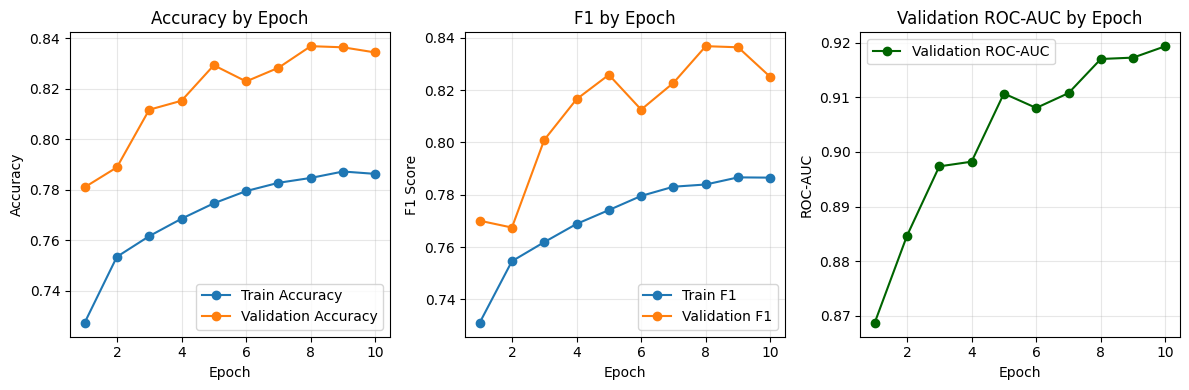

In [11]:
history_path = artifacts_dir / "history.json"
if history_path.exists():
    history = json.loads(history_path.read_text(encoding="utf-8"))
    epochs = [item["epoch"] for item in history]
    train_acc = [item["train"]["accuracy"] for item in history]
    val_acc = [item["valid"]["accuracy"] for item in history]
    train_f1 = [item["train"]["f1"] for item in history]
    val_f1 = [item["valid"]["f1"] for item in history]
    val_auc = [item["valid"]["roc_auc"] for item in history]

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.plot(epochs, train_acc, marker="o", label="Train Accuracy")
    plt.plot(epochs, val_acc, marker="o", label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy by Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 2)
    plt.plot(epochs, train_f1, marker="o", label="Train F1")
    plt.plot(epochs, val_f1, marker="o", label="Validation F1")
    plt.xlabel("Epoch")
    plt.ylabel("F1 Score")
    plt.title("F1 by Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.subplot(1, 3, 3)
    plt.plot(epochs, val_auc, marker="o", color="darkgreen", label="Validation ROC-AUC")
    plt.xlabel("Epoch")
    plt.ylabel("ROC-AUC")
    plt.title("Validation ROC-AUC by Epoch")
    plt.legend()
    plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()
else:
    print("history.json not found")

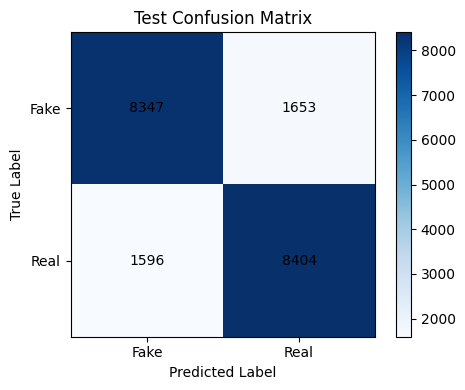

In [12]:
if test_metrics:
    cm = np.array(test_metrics["confusion_matrix"])
    labels = ["Fake", "Real"]

    plt.figure(figsize=(5, 4))
    plt.imshow(cm, cmap="Blues")
    plt.title("Test Confusion Matrix")
    plt.colorbar()
    plt.xticks([0, 1], labels)
    plt.yticks([0, 1], labels)
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            plt.text(j, i, int(cm[i, j]), ha="center", va="center", color="black")

    plt.tight_layout()
    plt.show()
else:
    print("test_metrics.json not found")

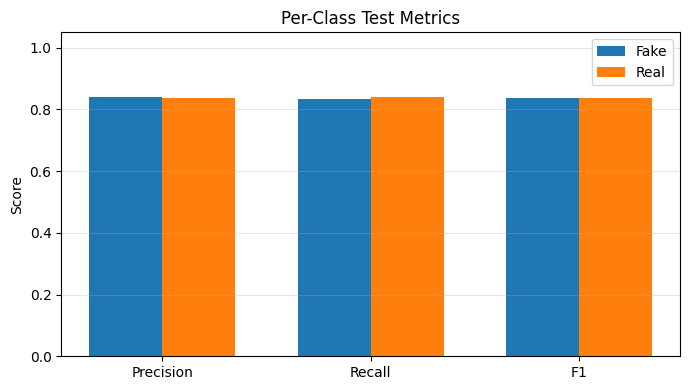

In [13]:
if test_metrics:
    fake_report = test_metrics["classification_report"]["fake"]
    real_report = test_metrics["classification_report"]["real"]
    metrics = ["precision", "recall", "f1-score"]
    fake_values = [fake_report[m] for m in metrics]
    real_values = [real_report[m] for m in metrics]

    x = np.arange(len(metrics))
    width = 0.35

    plt.figure(figsize=(7, 4))
    plt.bar(x - width / 2, fake_values, width, label="Fake")
    plt.bar(x + width / 2, real_values, width, label="Real")
    plt.xticks(x, ["Precision", "Recall", "F1"])
    plt.ylim(0.0, 1.05)
    plt.ylabel("Score")
    plt.title("Per-Class Test Metrics")
    plt.legend()
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("test_metrics.json not found")

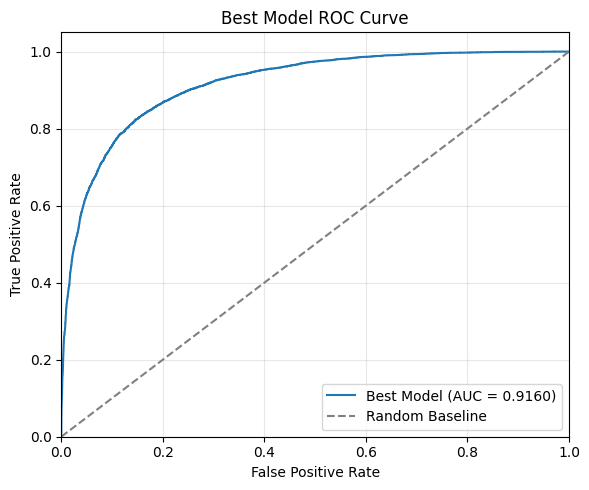

In [14]:
if roc_curve_path.exists():
    roc_curve = json.loads(roc_curve_path.read_text(encoding="utf-8"))
    fpr = roc_curve["fpr"]
    tpr = roc_curve["tpr"]
    auc_value = roc_curve.get("roc_auc") or (test_metrics.get("roc_auc") if test_metrics else None)

    plt.figure(figsize=(6, 5))
    plt.plot(fpr, tpr, label=f"Best Model (AUC = {auc_value:.4f})" if auc_value is not None else "Best Model")
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Baseline")
    plt.xlim(0.0, 1.0)
    plt.ylim(0.0, 1.05)
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("Best Model ROC Curve")
    plt.legend(loc="lower right")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
else:
    print("best_model_roc_curve.json not found. Re-run deepfake_training.ipynb to save ROC curve points for the best model.")